In [1]:
!bpip install opencv-python matplotlib numpy

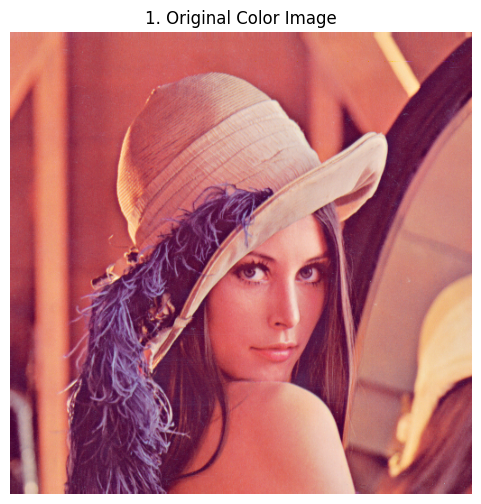

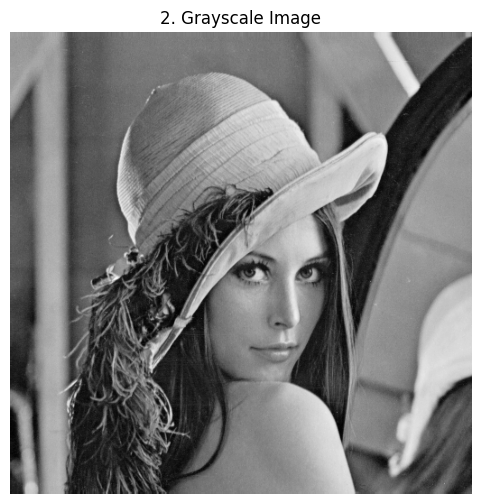

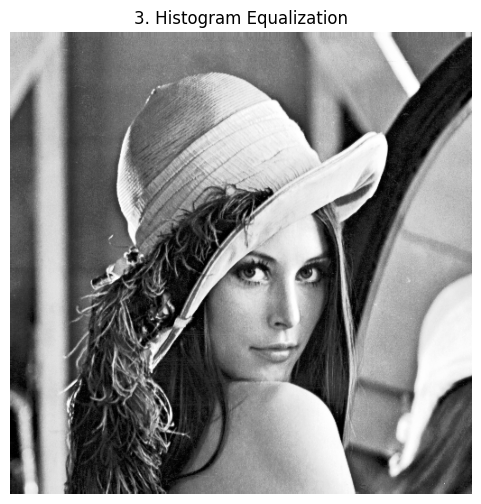

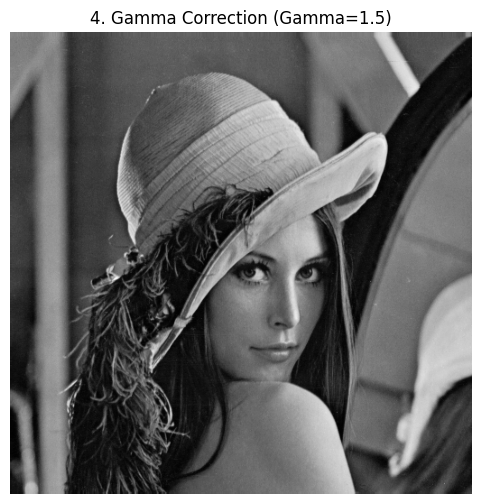

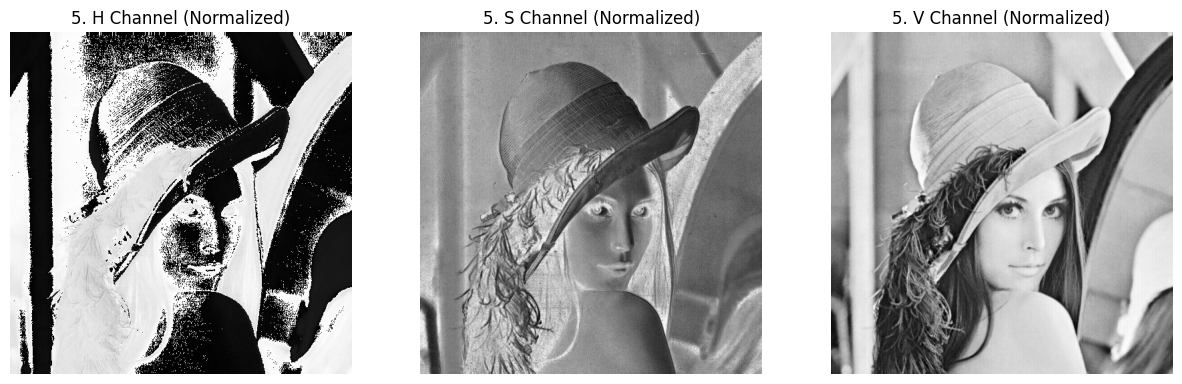

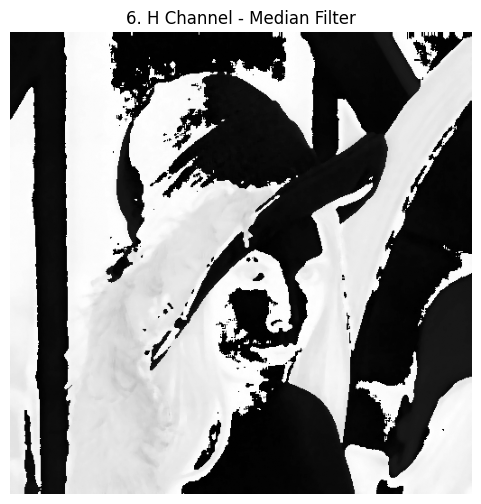

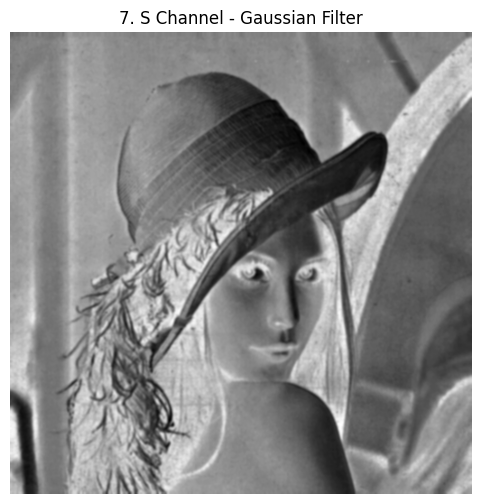

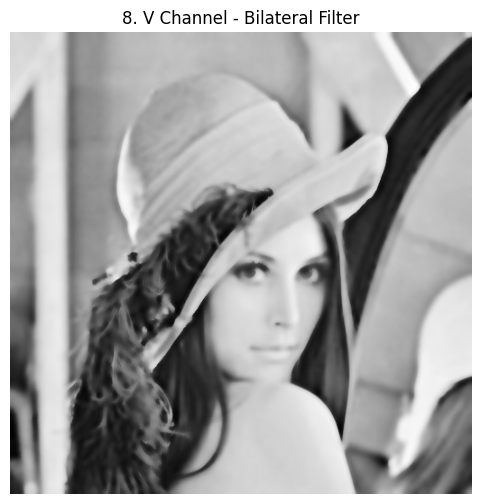

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_image(title, img, cmap=None):
    plt.figure(figsize=(6, 6))
    plt.title(title)
    if cmap:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.axis('off')
    plt.show()

# 1. Lena 이미지를 컬러영상으로 읽고 화면에 출력하시오.
img_bgr = cv2.imread('/content/Lena.png')

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
show_image("1. Original Color Image", img_rgb)

# 2. 영상을 흑백으로 변환하고 화면에 출력하시오
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
show_image("2. Grayscale Image", img_gray, cmap='gray')

# 3. 흑백으로 변환된 영상에 Histogram Equalization을 적용하고 출력하시오.
img_eq = cv2.equalizeHist(img_gray)
show_image("3. Histogram Equalization", img_eq, cmap='gray')

# 4. 흑백으로 변환된 영상에 Gamma Correction을 적용하고 출력하시오.
gamma = 1.5
img_gamma = np.array(255 * (img_gray / 255) ** gamma, dtype='uint8')
show_image(f"4. Gamma Correction (Gamma={gamma})", img_gamma, cmap='gray')

# 5. 영상을 HSV 컬러 스페이스로 변환하고 각각을 화면에 출력하시오.
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h, s, v = cv2.split(img_hsv)

h_norm = cv2.normalize(h, None, 0, 255, cv2.NORM_MINMAX)
s_norm = cv2.normalize(s, None, 0, 255, cv2.NORM_MINMAX)
v_norm = cv2.normalize(v, None, 0, 255, cv2.NORM_MINMAX)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1), plt.title("5. H Channel (Normalized)"), plt.imshow(h_norm, cmap='gray'), plt.axis('off')
plt.subplot(1, 3, 2), plt.title("5. S Channel (Normalized)"), plt.imshow(s_norm, cmap='gray'), plt.axis('off')
plt.subplot(1, 3, 3), plt.title("5. V Channel (Normalized)"), plt.imshow(v_norm, cmap='gray'), plt.axis('off')
plt.show()

# 6. H 채널에 대해서 Median Filter를 적용하고 출력하시오.
h_median = cv2.medianBlur(h_norm, 5)
show_image("6. H Channel - Median Filter", h_median, cmap='gray')

# 7. S 채널에 대해서 Gaussian Filter를 적용하고 출력하시오.
s_gaussian = cv2.GaussianBlur(s_norm, (5, 5), 0)
show_image("7. S Channel - Gaussian Filter", s_gaussian, cmap='gray')

# 8. V 채널에 대해서 Bilateral Filter를 적용하고 출력하시오.
v_bilateral = cv2.bilateralFilter(v_norm, d=9, sigmaColor=75, sigmaSpace=75)
show_image("8. V Channel - Bilateral Filter", v_bilateral, cmap='gray')